# SE-ResNet-50 — Diabetic Retinopathy Severity Grading
**Study:** DIABETIC RETINOPATHY SEVERITY CLASSIFICATION USING RESNET-50
AND SE-RESNET-50 ON RETINAL FUNDUS IMAGES 
**Model:** SE-ResNet-50 (Squeeze-and-Excitation Experimental) 
**Dataset:** APTOS 2019 (224×224 pre-processed) 
**Split:** 80/10/10 — IDENTICAL to ResNet-50 notebook (loaded from split_indices.json) 
**Epochs:** 50 fixed 
**Scheduler:** CosineAnnealingLR (identical, deterministic for both models) 
**NOTE:** The ONLY structural difference from ResNet-50 is the SE blocks inserted
into each bottleneck residual block. ALL other hyperparameters are identical.

## 0. Environment & Reproducibility

In [ ]:
import os
import random
import numpy as np
import torch

# Identical seed as ResNet-50 notebook 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED']       = str(SEED)

print(f'Seed set to {SEED}')
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

Seed set to 42
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


## 1. Configuration

In [ ]:
# Paths
DATASET_PATH    = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/colored_images"
OUTPUT_DIR      = "./outputs/se_resnet50_final"
SPLIT_JSON_PATH = "/kaggle/input/datasets/orestikoni/dr-split-indices/split_indices.json"  # created by ResNet-50 notebook
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Hyperparameters — IDENTICAL to ResNet-50 notebook 
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_CLASSES  = 5
NUM_EPOCHS   = 50
LR           = 1e-4
WEIGHT_DECAY = 1e-4
LR_MIN       = 1e-7    # eta_min for CosineAnnealingLR
NUM_WORKERS  = 2

# SE block reduction ratio
SE_REDUCTION = 16   # standard r=16 from Hu et al. (2018)

CLASS_NAMES = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {DEVICE}')
print(f'SE reduction    : {SE_REDUCTION}')
print(f'Scheduler       : CosineAnnealingLR (T_max={NUM_EPOCHS}, eta_min={LR_MIN})')

Device          : cuda
SE reduction    : 16
Scheduler       : CosineAnnealingLR (T_max=50, eta_min=1e-07)


## 2. Imports

In [3]:
import json
import time
import warnings
from pathlib import Path
from collections import OrderedDict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from torchvision.models.resnet import Bottleneck

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix,
    roc_auc_score, roc_curve, auc,
    matthews_corrcoef, cohen_kappa_score,
    mean_absolute_error
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
print('All imports successful.')

All imports successful.


## 3. SE Block & SE-ResNet-50 Architecture

In [ ]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block as described in Hu et al. (2019).

    Structure:
      1. Squeeze  : Global Average Pooling → channel descriptor [B, C, 1, 1]
      2. Excitation: FC(C → C/r) → ReLU → FC(C/r → C) → Sigmoid → scale vector
      3. Scale    : element-wise multiply scale onto input feature map

    Args:
        channels  : number of input channels (C)
        reduction : reduction ratio r (default 16)
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),                    # [B, C, H, W] → [B, C, 1, 1]
            nn.Flatten(),                               # [B, C]
            nn.Linear(channels, reduced, bias=False),   # FC down
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),   # FC up
            nn.Sigmoid()                                # scale ∈ (0, 1)
        )

    def forward(self, x):
        scale = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * scale


class SEBottleneck(nn.Module):
    """
    ResNet-50 Bottleneck block augmented with an SE block.

    The SE block is inserted AFTER the three conv layers and BEFORE
    the residual addition — identical to the placement in Hu et al. (2019).
    """
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None,
                 groups=1, base_width=64, dilation=1,
                 norm_layer=None, reduction=16):
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.0)) * groups

        self.conv1 = nn.Conv2d(inplanes, width, kernel_size=1, bias=False)
        self.bn1   = norm_layer(width)
        self.conv2 = nn.Conv2d(width, width, kernel_size=3,
                               stride=stride, padding=dilation,
                               groups=groups, bias=False, dilation=dilation)
        self.bn2   = norm_layer(width)
        self.conv3 = nn.Conv2d(width, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3   = norm_layer(planes * self.expansion)
        self.relu  = nn.ReLU(inplace=True)

        # SE block applied to output channels of conv3
        self.se_block   = SEBlock(planes * self.expansion, reduction=reduction)
        self.downsample = downsample
        self.stride     = stride

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        # SE recalibration BEFORE residual addition (Hu et al. 2018 placement)
        out = self.se_block(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out  = self.relu(out)
        return out


print('SEBlock and SEBottleneck defined.')

SEBlock and SEBottleneck defined.


In [5]:
def build_se_resnet50(num_classes: int, reduction: int = 16) -> nn.Module:
    """
    Build SE-ResNet-50 by:
      1. Loading a standard pretrained ResNet-50 (ImageNet weights)
      2. Replacing every Bottleneck block with SEBottleneck
      3. Copying all pretrained conv/bn weights into the new SE blocks
         (SE-specific FC layers remain randomly initialized)
      4. Replacing the final FC with Linear(2048 → num_classes)

    This ensures the backbone starts from the same pretrained weights
    as the ResNet-50 baseline — the only new parameters are the SE FCs.
    """
    base = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

    def replace_bottlenecks(layer, reduction):
        new_blocks = []
        for block in layer:
            # Read stride safely from conv2 (standard Bottleneck attribute)
            block_stride = block.conv2.stride[0]

            se_block = SEBottleneck(
                inplanes   = block.conv1.in_channels,
                planes     = block.conv3.out_channels // SEBottleneck.expansion,
                stride     = block_stride,
                downsample = block.downsample,
                reduction  = reduction
            )
            # Copy pretrained weights for conv and bn layers
            se_block.conv1.load_state_dict(block.conv1.state_dict())
            se_block.bn1.load_state_dict(block.bn1.state_dict())
            se_block.conv2.load_state_dict(block.conv2.state_dict())
            se_block.bn2.load_state_dict(block.bn2.state_dict())
            se_block.conv3.load_state_dict(block.conv3.state_dict())
            se_block.bn3.load_state_dict(block.bn3.state_dict())
            # SE block FC layers stay randomly initialized (new parameters)
            new_blocks.append(se_block)
        return nn.Sequential(*new_blocks)

    base.layer1 = replace_bottlenecks(base.layer1, reduction)
    base.layer2 = replace_bottlenecks(base.layer2, reduction)
    base.layer3 = replace_bottlenecks(base.layer3, reduction)
    base.layer4 = replace_bottlenecks(base.layer4, reduction)

    base.fc = nn.Linear(base.fc.in_features, num_classes)

    return base


model = build_se_resnet50(NUM_CLASSES, reduction=SE_REDUCTION).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
se_params        = sum(p.numel() for name, p in model.named_parameters() if 'se_block' in name)

print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'SE-specific params   : {se_params:,}  (randomly initialized, rest from ImageNet)')

Total parameters     : 26,033,221
Trainable parameters : 26,033,221
SE-specific params   : 2,514,944  (randomly initialized, rest from ImageNet)


## 4. Load Identical Split from ResNet-50 Notebook

In [6]:
with open(SPLIT_JSON_PATH, 'r') as f:
    split_data = json.load(f)

assert split_data['seed'] == SEED,              'Seed mismatch — ensure you load the correct split file.'
# class_names check skipped — ResNet-50 notebook saved the split; order updated in both notebooks

train_paths  = np.array([Path(p) for p in split_data['train_paths']])
val_paths    = np.array([Path(p) for p in split_data['val_paths']])
test_paths   = np.array([Path(p) for p in split_data['test_paths']])
train_labels = np.array(split_data['train_labels'])
val_labels   = np.array(split_data['val_labels'])
test_labels  = np.array(split_data['test_labels'])

print(f'Split loaded from: {SPLIT_JSON_PATH}')
print(f'Train : {len(train_labels)} | Val : {len(val_labels)} | Test : {len(test_labels)}')
print('Split verified — identical to ResNet-50 notebook.')

Split loaded from: /kaggle/input/datasets/orestikoni/dr-split-indices/split_indices.json
Train : 2929 | Val : 366 | Test : 367
Split verified — identical to ResNet-50 notebook.


## 5. Class Weights & WeightedRandomSampler

In [ ]:
# Identical computation as ResNet-50 notebook 
class_counts         = np.bincount(train_labels, minlength=NUM_CLASSES).astype(np.float32)
class_weights        = 1.0 / class_counts
class_weights        = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Class weights (inverse frequency, from train set only):')
for name, w, c in zip(CLASS_NAMES, class_weights, class_counts):
    print(f'  {name:<20} count={int(c):>4}  weight={w:.4f}')

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)
print(f'\nWeightedRandomSampler created with {len(sample_weights)} samples.')

Class weights (inverse frequency, from train set only):
  No_DR                count=1444  weight=0.2157
  Mild                 count= 296  weight=1.0522
  Moderate             count= 799  weight=0.3898
  Severe               count= 154  weight=2.0225
  Proliferate_DR       count= 236  weight=1.3198

WeightedRandomSampler created with 2929 samples.


## 6. Dataset Class & DataLoaders

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Identical transforms as ResNet-50 notebook
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


class DRDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


train_dataset = DRDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = DRDataset(val_paths,   val_labels,   transform=val_test_transform)
test_dataset  = DRDataset(test_paths,  test_labels,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 92
Val batches   : 12
Test batches  : 12


## 7. Loss, Optimizer & Scheduler

In [ ]:
# Identical setup as ResNet-50 notebook
criterion = nn.CrossEntropyLoss()  # WeightedRandomSampler handles imbalance; no dual penalty

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# CosineAnnealingLR: deterministic, identical schedule for both models
# LR decays from LR (1e-4) to LR_MIN (1e-7) following a cosine curve over
# NUM_EPOCHS epochs. No adaptive behaviour — ensures fair comparison.
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = NUM_EPOCHS,
    eta_min = LR_MIN
)

print('Loss      : CrossEntropyLoss (unweighted — WeightedRandomSampler handles imbalance)')
print('Optimizer : AdamW (lr=1e-4, weight_decay=1e-4)')
print(f'Scheduler : CosineAnnealingLR (T_max={NUM_EPOCHS}, eta_min={LR_MIN})')

Loss      : CrossEntropyLoss (unweighted — WeightedRandomSampler handles imbalance)
Optimizer : AdamW (lr=1e-4, weight_decay=1e-4)
Scheduler : CosineAnnealingLR (T_max=50, eta_min=1e-07)


## 8. Training Loop

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss = running_loss / total
    val_acc  = correct / total
    val_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return val_loss, val_acc, val_f1


# Training
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': [], 'lr': []}
best_val_loss  = float('inf')
best_ckpt_path = os.path.join(OUTPUT_DIR, 'best_se_resnet50.pth')

print(f'Starting training — {NUM_EPOCHS} epochs\n')
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc        = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc, val_f1  = validate(model, val_loader, criterion, DEVICE)

    # CosineAnnealingLR steps unconditionally each epoch (no argument needed)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_ckpt_path)
        saved = '  ✓ saved'
    else:
        saved = ''

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    elapsed = time.time() - t0
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  '
          f'val_f1={val_f1:.4f}  lr={current_lr:.2e}  '
          f'[{elapsed:.1f}s]{saved}')

with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'w') as f:
    json.dump(history, f)
print(f'\nBest val_loss: {best_val_loss:.4f}  →  checkpoint: {best_ckpt_path}')

Starting training — 50 epochs

Epoch [01/50]  train_loss=1.0083  train_acc=0.5879  val_loss=0.6417  val_acc=0.7650  val_f1=0.6279  lr=9.99e-05  [39.4s]  ✓ saved
Epoch [02/50]  train_loss=0.7363  train_acc=0.7105  val_loss=0.5190  val_acc=0.7978  val_f1=0.6311  lr=9.96e-05  [40.2s]  ✓ saved
Epoch [03/50]  train_loss=0.6511  train_acc=0.7545  val_loss=0.5096  val_acc=0.7978  val_f1=0.6484  lr=9.91e-05  [45.5s]  ✓ saved
Epoch [04/50]  train_loss=0.5780  train_acc=0.7805  val_loss=0.5493  val_acc=0.8060  val_f1=0.6309  lr=9.84e-05  [44.1s]
Epoch [05/50]  train_loss=0.4735  train_acc=0.8266  val_loss=0.6109  val_acc=0.7705  val_f1=0.6072  lr=9.76e-05  [45.5s]
Epoch [06/50]  train_loss=0.4431  train_acc=0.8354  val_loss=0.5631  val_acc=0.8361  val_f1=0.6684  lr=9.65e-05  [44.9s]
Epoch [07/50]  train_loss=0.3650  train_acc=0.8692  val_loss=0.5091  val_acc=0.8306  val_f1=0.6967  lr=9.52e-05  [46.2s]  ✓ saved
Epoch [08/50]  train_loss=0.3273  train_acc=0.8802  val_loss=0.5043  val_acc=0.8197  v

## 9. Training Curves

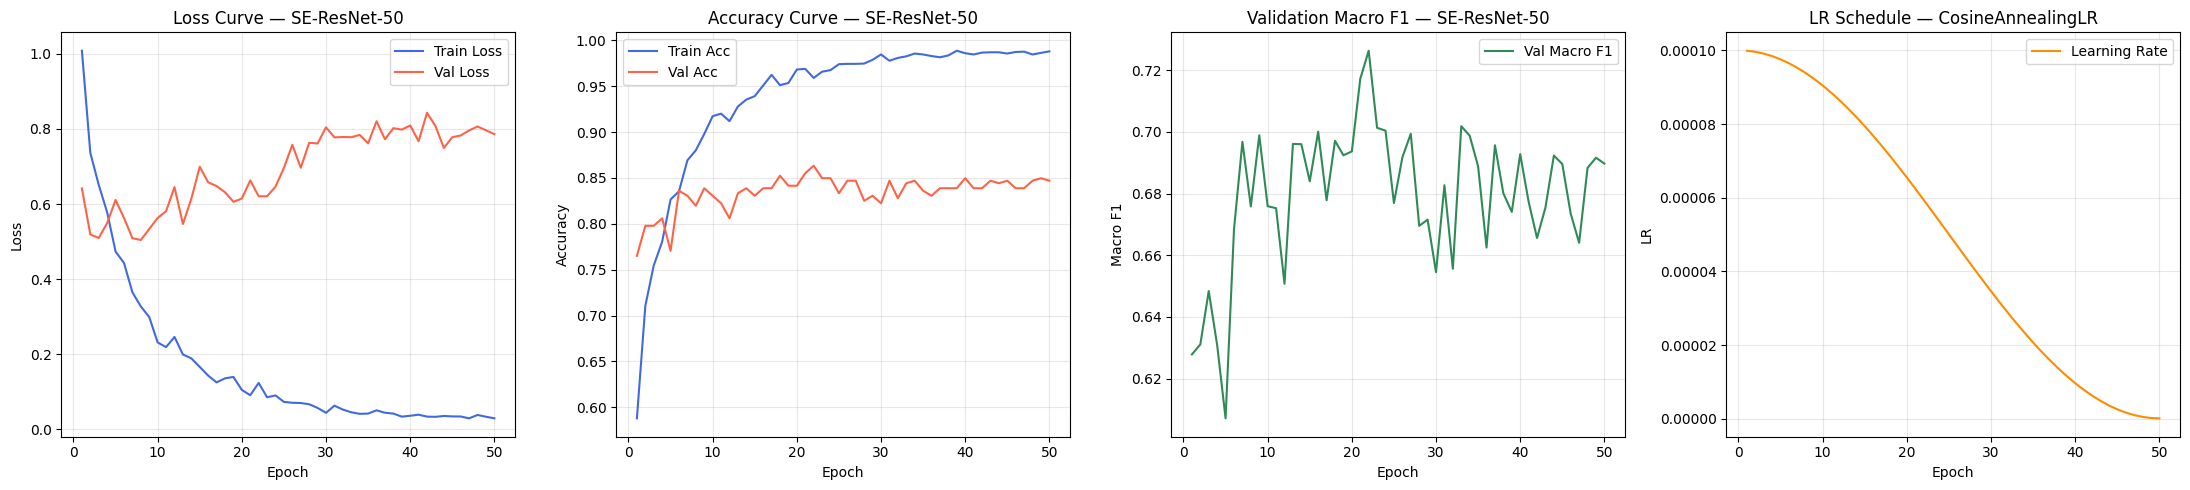

In [11]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss Curve — SE-ResNet-50')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', color='royalblue')
axes[1].plot(epochs_range, history['val_acc'],   label='Val Acc',   color='tomato')
axes[1].set_title('Accuracy Curve — SE-ResNet-50')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_f1'], label='Val Macro F1', color='seagreen')
axes[2].set_title('Validation Macro F1 — SE-ResNet-50')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Macro F1')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

# LR curve — confirms cosine decay shape (validates protocol)
axes[3].plot(epochs_range, history['lr'], label='Learning Rate', color='darkorange')
axes[3].set_title('LR Schedule — CosineAnnealingLR')
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('LR')
axes[3].legend(); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 10. Inference on Test Set

In [12]:
model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))
model.eval()

all_preds, all_labels_test, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = probs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_test.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds       = np.array(all_preds)
all_labels_test = np.array(all_labels_test)
all_probs       = np.array(all_probs)

print(f'Test inference complete. Total samples: {len(all_preds)}')

Test inference complete. Total samples: 367


## 11. Evaluation Metrics

In [ ]:
# TIER 1 — Primary Metrics
accuracy        = accuracy_score(all_labels_test, all_preds)
macro_f1        = f1_score(all_labels_test, all_preds, average='macro',    zero_division=0)
weighted_f1     = f1_score(all_labels_test, all_preds, average='weighted', zero_division=0)
macro_precision = precision_score(all_labels_test, all_preds, average='macro',    zero_division=0)
macro_recall    = recall_score(all_labels_test,    all_preds, average='macro',    zero_division=0)
qwk             = cohen_kappa_score(all_labels_test, all_preds, weights='quadratic')
linear_kappa    = cohen_kappa_score(all_labels_test, all_preds, weights='linear')

per_class_precision = precision_score(all_labels_test, all_preds, average=None, zero_division=0)
per_class_recall    = recall_score(all_labels_test,    all_preds, average=None, zero_division=0)
per_class_f1        = f1_score(all_labels_test,        all_preds, average=None, zero_division=0)

print('═' * 60)
print('TIER 1 — PRIMARY METRICS')
print('═' * 60)
print(f'  Accuracy              : {accuracy:.4f}')
print(f'  Macro F1-Score        : {macro_f1:.4f}')
print(f'  Weighted F1-Score     : {weighted_f1:.4f}')
print(f'  Macro Precision       : {macro_precision:.4f}')
print(f'  Macro Recall          : {macro_recall:.4f}')
print(f'  Quadratic Weighted Kappa (QWK) : {qwk:.4f}')
print(f'  Linear Kappa          : {linear_kappa:.4f}')
print()
print(f'  {"Class":<20} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('  ' + '-' * 52)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<20} {per_class_precision[i]:>10.4f} {per_class_recall[i]:>10.4f} {per_class_f1[i]:>10.4f}')

════════════════════════════════════════════════════════════
TIER 1 — PRIMARY METRICS
════════════════════════════════════════════════════════════
  Accuracy              : 0.8338
  Macro F1-Score        : 0.7200
  Weighted F1-Score     : 0.8347
  Macro Precision       : 0.7179
  Macro Recall          : 0.7309
  Quadratic Weighted Kappa (QWK) : 0.9085
  Linear Kappa          : 0.8451

  Class                 Precision     Recall         F1
  ----------------------------------------------------
  No_DR                    0.9624     0.9890     0.9755
  Mild                     0.5400     0.7297     0.6207
  Moderate                 0.8415     0.6900     0.7582
  Severe                   0.5789     0.5789     0.5789
  Proliferate_DR           0.6667     0.6667     0.6667


In [ ]:
# TIER 2 — Supporting Metrics 
labels_bin    = label_binarize(all_labels_test, classes=list(range(NUM_CLASSES)))
roc_auc_macro = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average='macro')
per_class_auc = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average=None)
mcc           = matthews_corrcoef(all_labels_test, all_preds)
cm_raw        = confusion_matrix(all_labels_test, all_preds)
cm_norm       = confusion_matrix(all_labels_test, all_preds, normalize='true')

specificity = []
for i in range(NUM_CLASSES):
    tp = cm_raw[i, i]
    fn = cm_raw[i, :].sum() - tp
    fp = cm_raw[:, i].sum() - tp
    tn = cm_raw.sum() - tp - fn - fp
    specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

print('═' * 60)
print('TIER 2 — SUPPORTING METRICS')
print('═' * 60)
print(f'  ROC-AUC Macro OvR     : {roc_auc_macro:.4f}')
print(f'  MCC                   : {mcc:.4f}')
print()
print(f'  {"Class":<20} {"AUC":>10} {"Specificity":>12}')
print('  ' + '-' * 44)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<20} {per_class_auc[i]:>10.4f} {specificity[i]:>12.4f}')

════════════════════════════════════════════════════════════
TIER 2 — SUPPORTING METRICS
════════════════════════════════════════════════════════════
  ROC-AUC Macro OvR     : 0.9535
  MCC                   : 0.7526

  Class                       AUC  Specificity
  --------------------------------------------
  No_DR                    0.9962       0.9624
  Mild                     0.9245       0.9303
  Moderate                 0.9464       0.9513
  Severe                   0.9599       0.9770
  Proliferate_DR           0.9402       0.9703


In [ ]:
# TIER 3 — Additional Metrics
mae_ordinal = mean_absolute_error(all_labels_test, all_preds)

print('═' * 60)
print('TIER 3 — ADDITIONAL METRICS')
print('═' * 60)
print(f'  MAE (ordinal labels)  : {mae_ordinal:.4f}')

metrics = {
    'model'           : 'SE-ResNet-50',
    'accuracy'        : float(accuracy),
    'macro_f1'        : float(macro_f1),
    'weighted_f1'     : float(weighted_f1),
    'macro_precision' : float(macro_precision),
    'macro_recall'    : float(macro_recall),
    'qwk'             : float(qwk),
    'linear_kappa'    : float(linear_kappa),
    'roc_auc_macro'   : float(roc_auc_macro),
    'mcc'             : float(mcc),
    'mae_ordinal'     : float(mae_ordinal),
    'per_class': {
        name: {
            'precision'  : float(per_class_precision[i]),
            'recall'     : float(per_class_recall[i]),
            'f1'         : float(per_class_f1[i]),
            'auc'        : float(per_class_auc[i]),
            'specificity': float(specificity[i])
        } for i, name in enumerate(CLASS_NAMES)
    }
}
with open(os.path.join(OUTPUT_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('\nAll metrics saved to metrics.json')

════════════════════════════════════════════════════════════
TIER 3 — ADDITIONAL METRICS
════════════════════════════════════════════════════════════
  MAE (ordinal labels)  : 0.2098

All metrics saved to metrics.json


## 12. Confusion Matrices

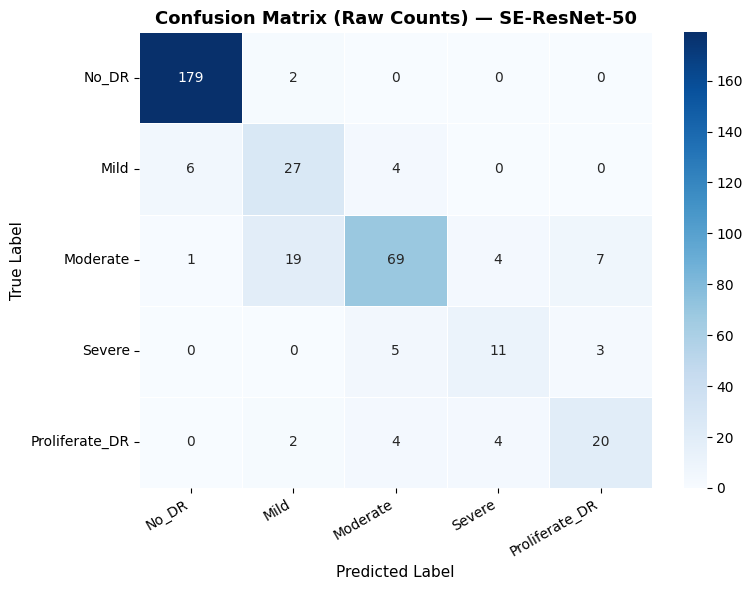

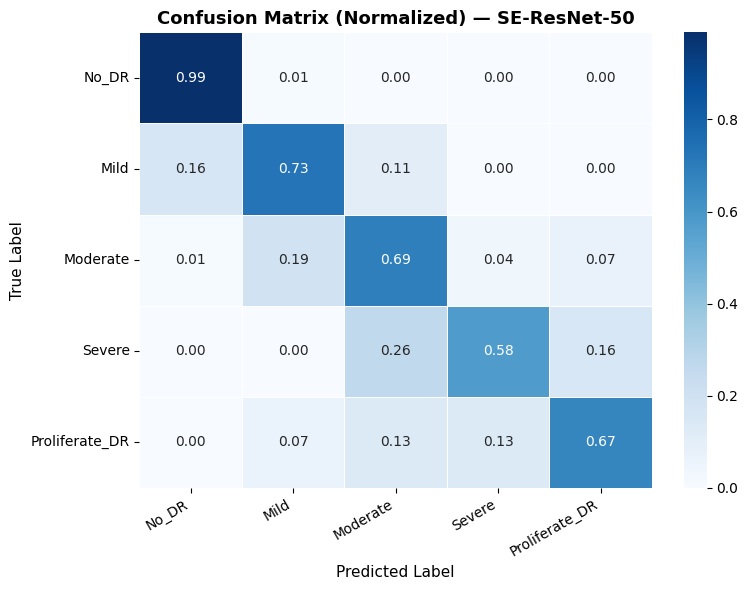

In [16]:
def plot_confusion_matrix(cm, class_names, title, normalize=False, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    fmt = '.2f' if normalize else 'd'
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_confusion_matrix(cm_raw,  CLASS_NAMES, 'Confusion Matrix (Raw Counts) — SE-ResNet-50',
                      normalize=False, save_path=os.path.join(OUTPUT_DIR, 'cm_raw.png'))
plot_confusion_matrix(cm_norm, CLASS_NAMES, 'Confusion Matrix (Normalized) — SE-ResNet-50',
                      normalize=True,  save_path=os.path.join(OUTPUT_DIR, 'cm_normalized.png'))

## 13. Per-Class ROC-AUC Curves

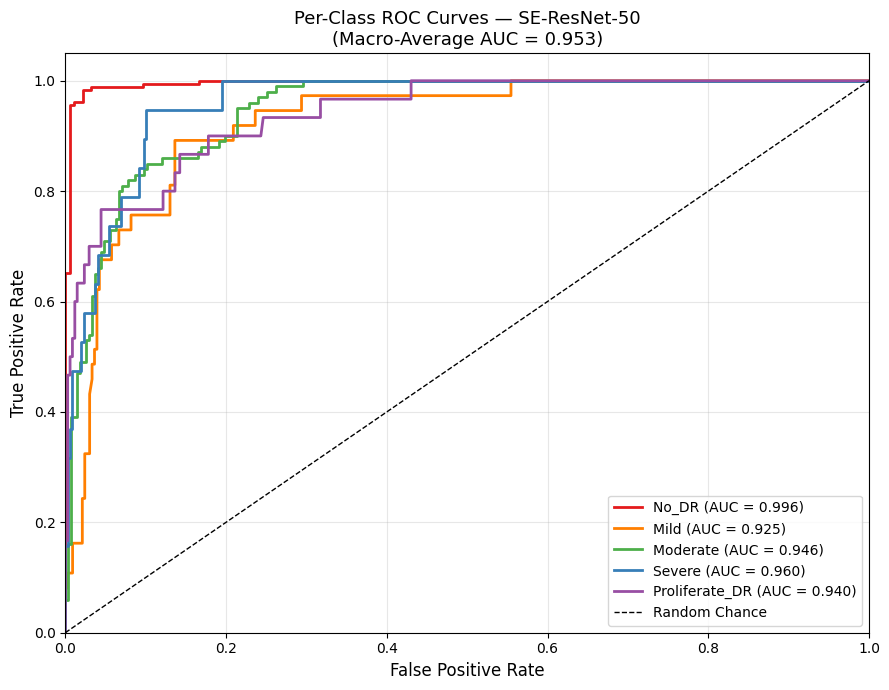

In [17]:
colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8', '#984ea3']
fig, ax = plt.subplots(figsize=(9, 7))

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc_i   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'Per-Class ROC Curves — SE-ResNet-50\n(Macro-Average AUC = {roc_auc_macro:.3f})', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150)
plt.show()

## 14. Grad-CAM Heatmaps

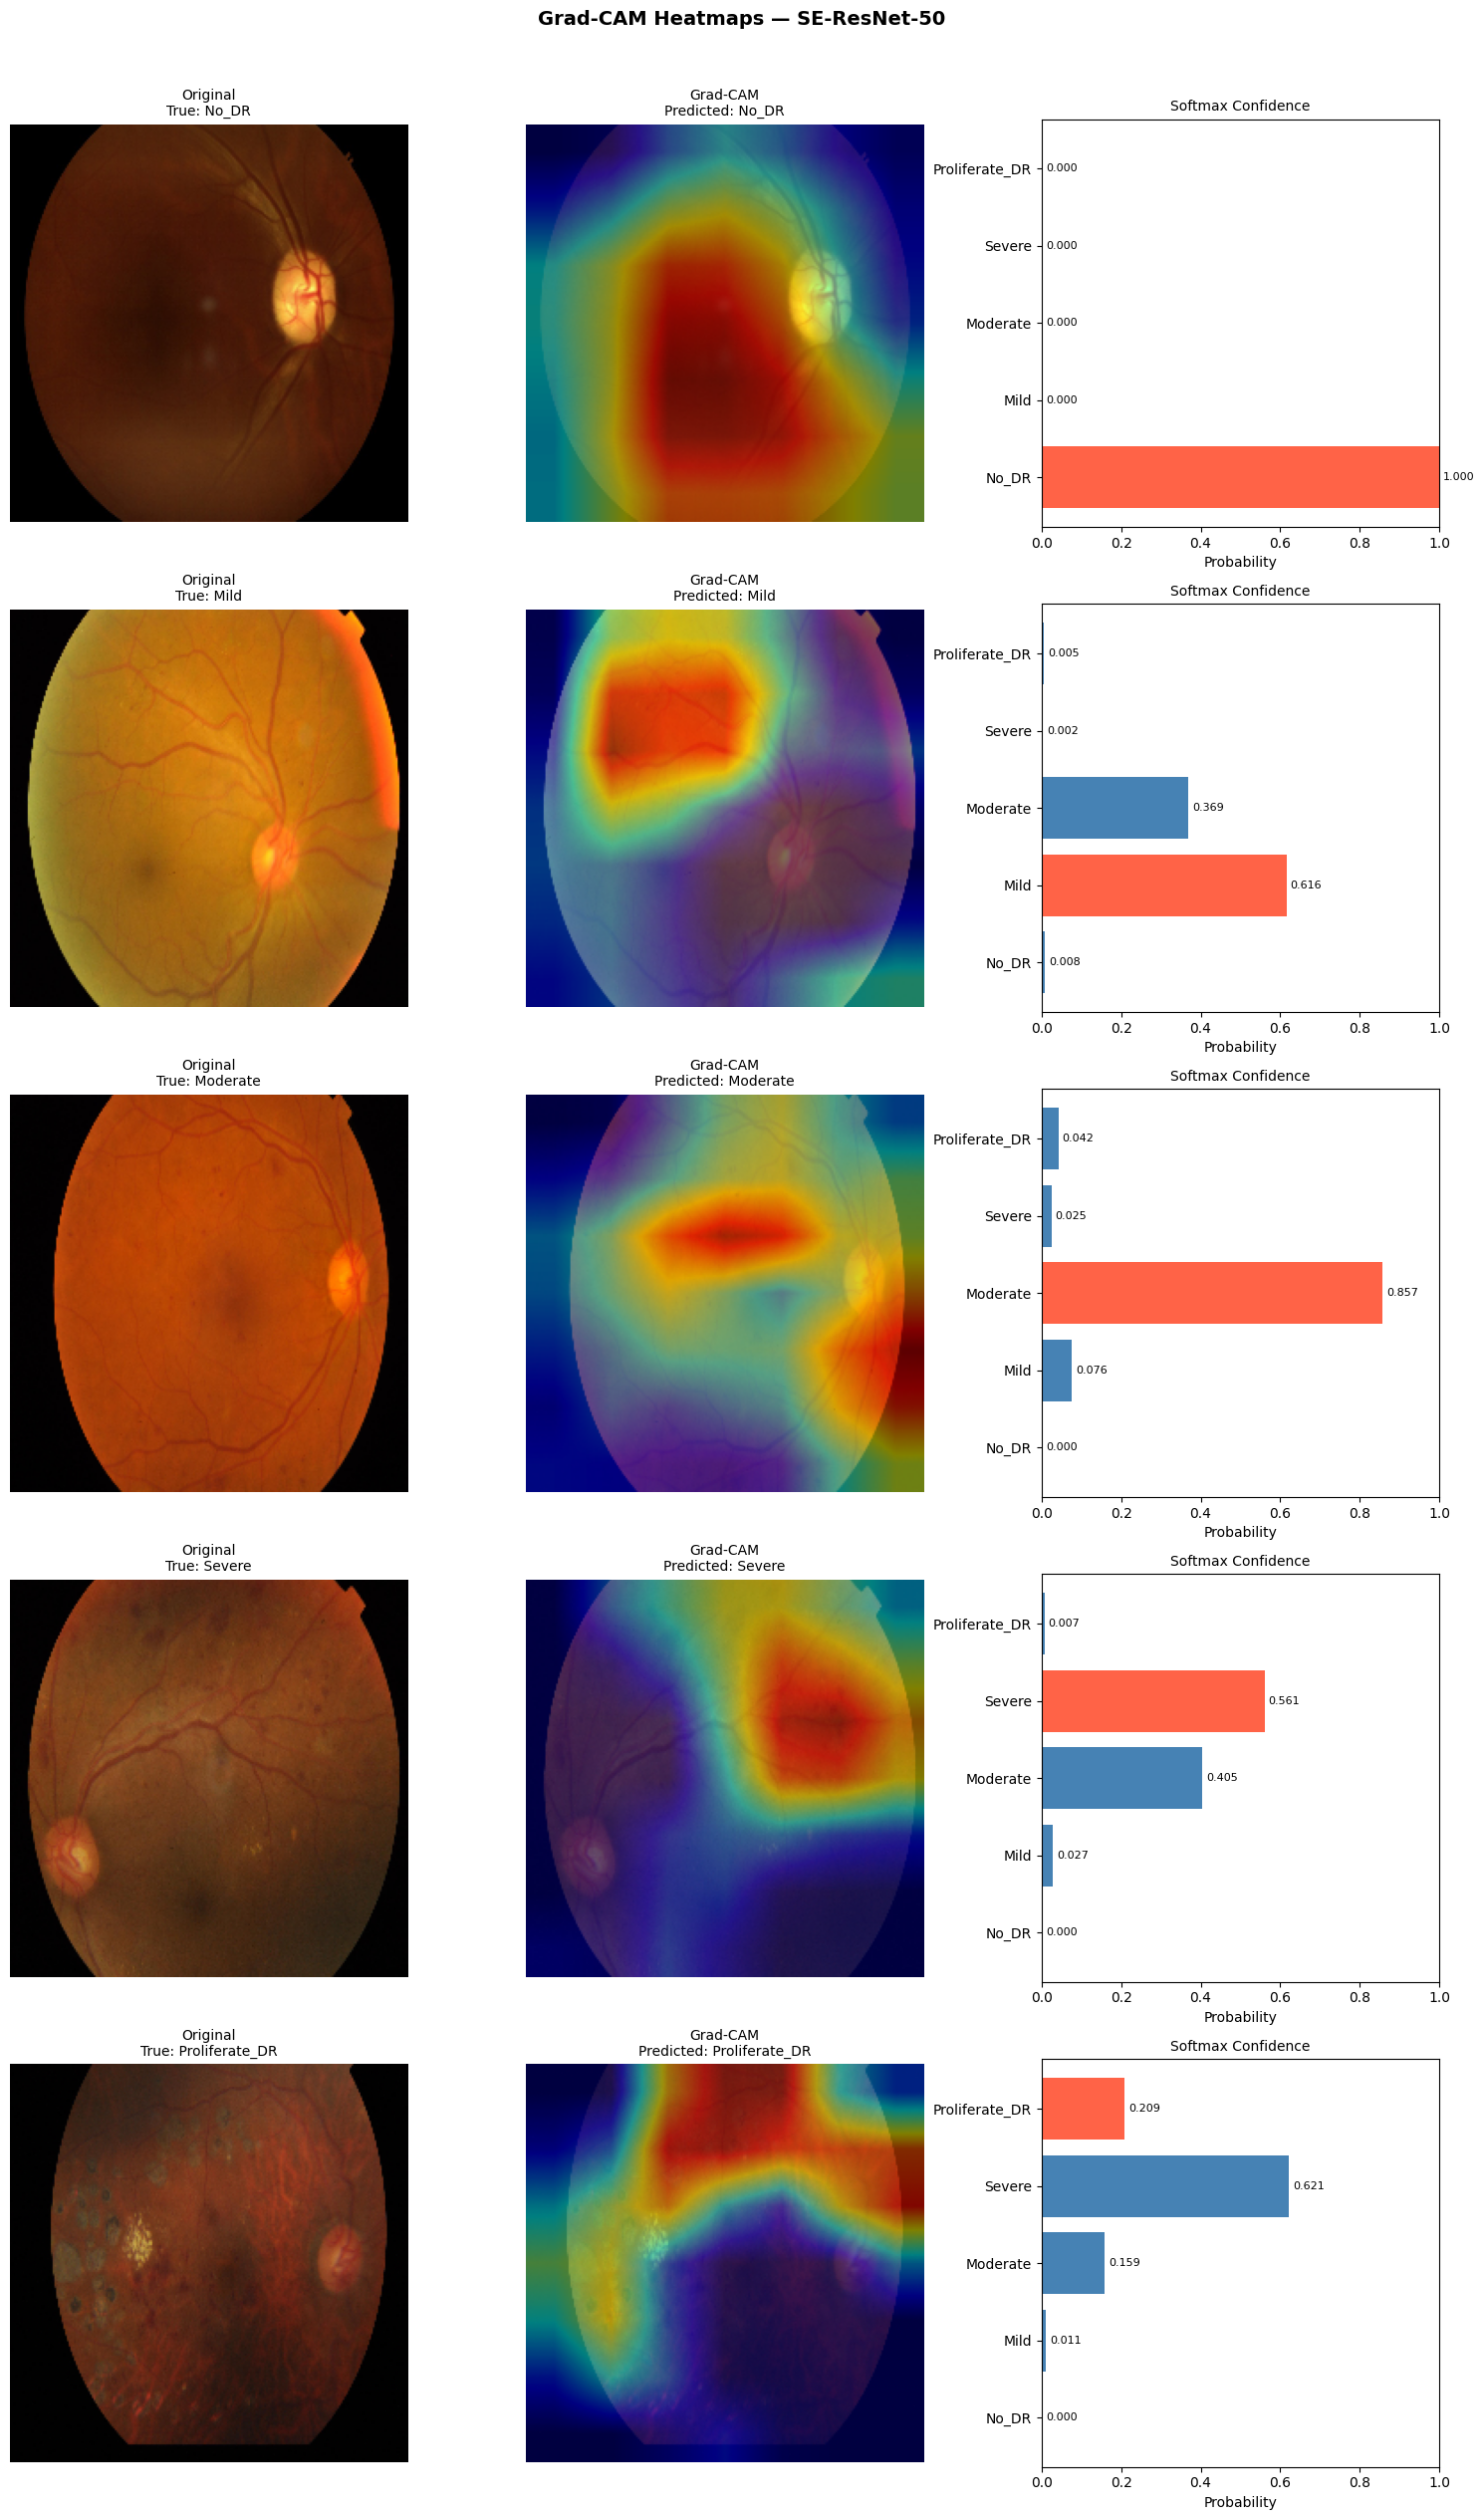

In [ ]:
class GradCAM:
    # Grad-CAM for SE-ResNet-50. Hooks into the final conv layer (layer4).
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self._register_hooks(target_layer)

    def _register_hooks(self, target_layer):
        # Named inner functions — cleaner pattern, hooks do not stack on re-call
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        probs   = torch.softmax(output, dim=1).squeeze().detach().cpu().numpy()
        return cam, class_idx, probs


def overlay_gradcam(img_pil, cam, size=224, alpha=0.5):
    img_np      = np.array(img_pil.resize((size, size)))
    cam_resized = cv2.resize(cam, (size, size))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return (alpha * heatmap + (1 - alpha) * img_np).astype(np.uint8)


# Hook into the last SEBottleneck of layer4
grad_cam = GradCAM(model, model.layer4[-1])

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(15, 5 * NUM_CLASSES))

for class_idx, class_name in enumerate(CLASS_NAMES):
    sample_indices = np.where(test_labels == class_idx)[0]
    if len(sample_indices) == 0:
        continue
    idx        = sample_indices[0]
    img_pil    = Image.open(test_paths[idx]).convert('RGB')
    img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)

    cam, pred_idx, probs = grad_cam.generate(img_tensor, class_idx=class_idx)
    overlay = overlay_gradcam(img_pil, cam)

    axes[class_idx, 0].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    axes[class_idx, 0].set_title(f'Original\nTrue: {class_name}', fontsize=10)
    axes[class_idx, 0].axis('off')

    axes[class_idx, 1].imshow(overlay)
    axes[class_idx, 1].set_title(f'Grad-CAM\nPredicted: {CLASS_NAMES[pred_idx]}', fontsize=10)
    axes[class_idx, 1].axis('off')

    bar_colors = ['tomato' if i == pred_idx else 'steelblue' for i in range(NUM_CLASSES)]
    axes[class_idx, 2].barh(CLASS_NAMES, probs, color=bar_colors)
    axes[class_idx, 2].set_xlim([0, 1])
    axes[class_idx, 2].set_title('Softmax Confidence', fontsize=10)
    axes[class_idx, 2].set_xlabel('Probability')
    for j, v in enumerate(probs):
        axes[class_idx, 2].text(v + 0.01, j, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Grad-CAM Heatmaps — SE-ResNet-50', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gradcam_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Summary Table

In [19]:
print('\n' + '═' * 65)
print('  FINAL RESULTS SUMMARY — SE-ResNet-50 (Best Checkpoint @ 50 Epochs)')
print('═' * 65)
print(f'  Accuracy              : {accuracy:.4f}')
print(f'  Macro F1              : {macro_f1:.4f}')
print(f'  Weighted F1           : {weighted_f1:.4f}')
print(f'  Macro Precision       : {macro_precision:.4f}')
print(f'  Macro Recall          : {macro_recall:.4f}')
print(f'  QWK                   : {qwk:.4f}')
print(f'  Linear Kappa          : {linear_kappa:.4f}')
print(f'  ROC-AUC Macro OvR     : {roc_auc_macro:.4f}')
print(f'  MCC                   : {mcc:.4f}')
print(f'  MAE (ordinal)         : {mae_ordinal:.4f}')
print()
print(f'  {"Class":<20} {"P":>6} {"R":>6} {"F1":>6} {"AUC":>6} {"Spec":>6}')
print('  ' + '-' * 56)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<20} '
          f'{per_class_precision[i]:>6.3f} '
          f'{per_class_recall[i]:>6.3f} '
          f'{per_class_f1[i]:>6.3f} '
          f'{per_class_auc[i]:>6.3f} '
          f'{specificity[i]:>6.3f}')
print('═' * 65)
print(f'  All outputs saved to: {OUTPUT_DIR}')


═════════════════════════════════════════════════════════════════
  FINAL RESULTS SUMMARY — SE-ResNet-50 (Best Checkpoint @ 50 Epochs)
═════════════════════════════════════════════════════════════════
  Accuracy              : 0.8338
  Macro F1              : 0.7200
  Weighted F1           : 0.8347
  Macro Precision       : 0.7179
  Macro Recall          : 0.7309
  QWK                   : 0.9085
  Linear Kappa          : 0.8451
  ROC-AUC Macro OvR     : 0.9535
  MCC                   : 0.7526
  MAE (ordinal)         : 0.2098

  Class                     P      R     F1    AUC   Spec
  --------------------------------------------------------
  No_DR                 0.962  0.989  0.975  0.996  0.962
  Mild                  0.540  0.730  0.621  0.925  0.930
  Moderate              0.841  0.690  0.758  0.946  0.951
  Severe                0.579  0.579  0.579  0.960  0.977
  Proliferate_DR        0.667  0.667  0.667  0.940  0.970
════════════════════════════════════════════════════════════